### Implement the Model - Random Forest

### 1. Import the python libraries

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline 
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import joblib
import gc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.base import BaseEstimator, ClassifierMixin

### 2. Import the data 

In [3]:
train_filepath = '../data/processed/neiss_feature-engineered_train_data.parquet'
eval_filepath = '../data/processed/neiss_feature-engineered_eval_data.parquet'
holdout_filepath =  '../data/processed/neiss_feature-engineered_holdout_data.parquet'

In [4]:
train_data= pd.read_parquet(train_filepath)
eval_data = pd.read_parquet(eval_filepath)
holdout_data = pd.read_parquet(holdout_filepath)

### 3. Setup the train/evaluation dataset

In [5]:
X_train = train_data.drop(columns=['Hospitalized'])
y_train = train_data['Hospitalized']
X_eval = eval_data.drop(columns=['Hospitalized'])
y_eval = eval_data['Hospitalized']

### 4. Run Random Forest with Majority Undersampling technique

In [6]:
print("Initializing Random Forest Pipeline...")

# Define the undersampler
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# Initialize the decisoin tree algorithm
random_forest = RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        min_samples_leaf=20, 
        random_state=42,
        n_jobs=-1 
    )
# Build the pipeline
model_pipeline = Pipeline(steps=[
        ('undersampler', rus),
        ('classifier', random_forest)
    ])

print("Training model (undersampling majority class)...")
# Fit the model on train dataset
model_pipeline.fit(X_train, y_train)


Initializing Random Forest Pipeline...
Training model (undersampling majority class)...


,steps,"[('undersampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'majority'
,random_state,42
,replacement,False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


### 5. Evaluate the results

In [7]:
print("\nEvaluating on Validation (Eval) Set...")
y_pred = model_pipeline.predict(X_eval)

# Print the Results
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_eval, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_eval, y_pred))


Evaluating on Validation (Eval) Set...

--- Confusion Matrix ---
[[778208 219311]
 [ 23512  76213]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.78      0.87    997519
           1       0.26      0.76      0.39     99725

    accuracy                           0.78   1097244
   macro avg       0.61      0.77      0.63   1097244
weighted avg       0.91      0.78      0.82   1097244



### 6. Plot the RUC-AUC Curve

Generating Final ROC-AUC Curve for Random Forest...


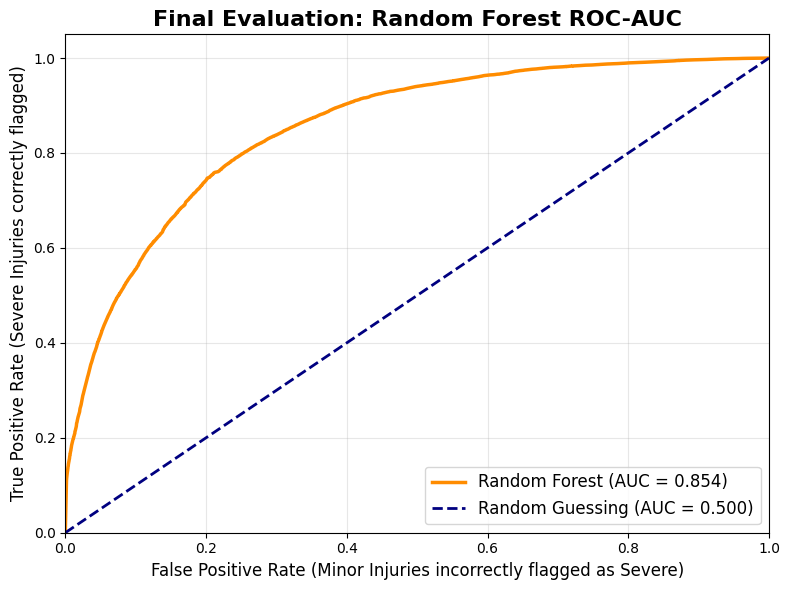

In [8]:


def plot_single_roc(model_pipeline, X_test, y_test, model_name="Final Champion Model"):
    """
    Calculates probabilities and plots the ROC-AUC curve for a single trained model 
    against the Hold-Out Test dataset.
    """
    print(f"Generating Final ROC-AUC Curve for {model_name}...")
    
    # 1. Get the probability that the patient is in the Positive Class (Hospitalized)
    # .predict_proba() returns [Probability_Released, Probability_Hospitalized]
    # We slice [:, 1] to grab only the Hospitalized probabilities.
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    
    # 2. Calculate the False Positive Rate (fpr) and True Positive Rate (tpr)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # 3. Calculate the Area Under the Curve (AUC) score
    roc_auc = auc(fpr, tpr)
    
    # 4. Set up the plotting canvas
    plt.figure(figsize=(8, 6))
    
    # 5. Plot the Model's Curve
    # We use a bold color (like dark orange) to make it pop for presentations
    plt.plot(fpr, tpr, color='darkorange', lw=2.5, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

    # 6. Plot the "Coin Flip" Baseline (Random Guessing)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Guessing (AUC = 0.500)')

    # 7. Format the Graph for Professional Presentation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Minor Injuries incorrectly flagged as Severe)', fontsize=12)
    plt.ylabel('True Positive Rate (Severe Injuries correctly flagged)', fontsize=12)
    plt.title(f'Final Evaluation: {model_name} ROC-AUC', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    # 8. Display the Graph
    plt.tight_layout()
    plt.show()

plot_single_roc(random_forest, X_eval, y_eval, model_name="Random Forest")

### 7. Hypertuning - FInding the optimal parameters

In [13]:


class CustomThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.50):
        """
        A wrapper for Scikit-Learn classifiers to use a custom prediction threshold.
        """
        self.estimator = estimator
        self.threshold = threshold

    def fit(self, X, y, **fit_params):
        """
        Fit the underlying estimator.
        """
        self.estimator.fit(X, y, **fit_params)
        
        # Scikit-Learn expects classifiers to have a classes_ attribute after fitting
        self.classes_ = self.estimator.classes_
        return self

    def predict(self, X):
        """
        Predict using the custom probability threshold.
        """
        # Extract probabilities for the positive class (index 1)
        probabilities = self.estimator.predict_proba(X)[:, 1]
        
        # Apply the threshold and convert boolean to integer (0 or 1)
        return (probabilities >= self.threshold).astype(int)

    def predict_proba(self, X):
        """
        Pass through the predict_proba method from the underlying estimator.
        """
        return self.estimator.predict_proba(X)

--- Random Forest Optimization Results ---
Optimal Probability Threshold: 0.6252
Maximum F1-Score: 0.4445
Precision at Optimal: 0.4111
Recall at Optimal: 0.4837

--- New Optimized Confusion Matrix ---
[[928424  69095]
 [ 51486  48239]]


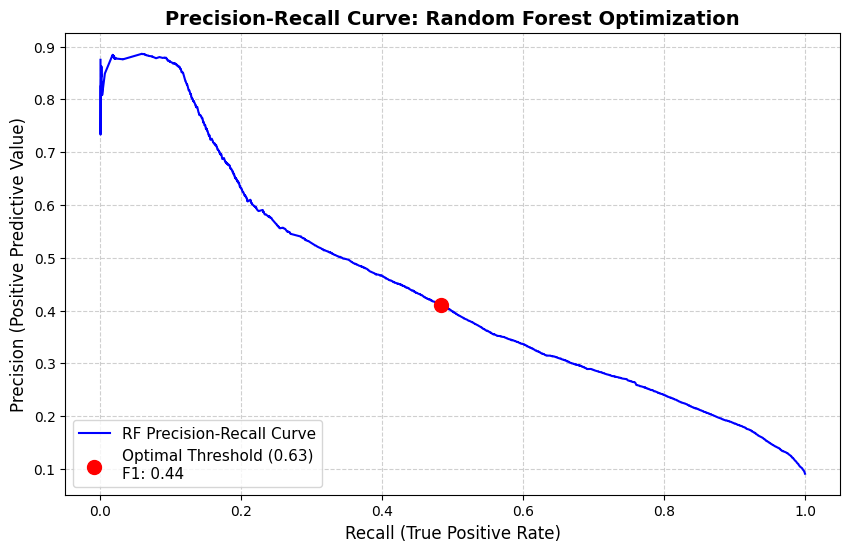

In [17]:

# 1. Get the raw vote probabilities from your trained Random Forest
# (Assuming rf_model is trained and X_test/y_test are defined)
y_scores_rf = random_forest.predict_proba(X_eval)[:, 1]

# 2. Calculate Precision, Recall, and Thresholds using scikit-learn
precisions, recalls, thresholds = precision_recall_curve(y_eval, y_scores_rf)

# 3. Calculate the F1-score for every single threshold
# We use a tiny epsilon (1e-8) to avoid accidental division by zero
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

# 4. Find the index of the absolute highest F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]


print(f"--- Random Forest Optimization Results ---")
print(f"Optimal Probability Threshold: {optimal_threshold:.4f}")
print(f"Maximum F1-Score: {optimal_f1:.4f}")
print(f"Precision at Optimal: {optimal_precision:.4f}")
print(f"Recall at Optimal: {optimal_recall:.4f}")

# Apply the new custom threshold to your test set
# # "If probability >= optimal_threshold, predict 1. Else, predict 0."
y_pred_optimized = np.where(y_scores_rf >= optimal_threshold, 1, 0)

print("\n--- New Optimized Confusion Matrix ---")
print(confusion_matrix(y_eval, y_pred_optimized))


# 5. Plot the Precision-Recall Curve for your CRISP-DM Report
plt.figure(figsize=(10, 6))

# Plot the main PR curve
plt.plot(recalls[:-1], precisions[:-1], color='blue', label='RF Precision-Recall Curve')

# Mark the exact optimal threshold point on the curve
plt.scatter(optimal_recall, optimal_precision, color='red', marker='o', s=100, zorder=5, 
            label=f'Optimal Threshold ({optimal_threshold:.2f})\nF1: {optimal_f1:.2f}')

# Formatting the chart for the report
plt.title('Precision-Recall Curve: Random Forest Optimization', fontsize=14, fontweight='bold')
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot out as an image file so you can drop it into your document
plt.savefig('rf_pr_curve_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

final_model = CustomThresholdClassifier(estimator=random_forest, threshold=optimal_threshold)


### 8. Export the models

In [18]:
print("Exporting Random Forest pipeline to disk...")
model_path = '../models/neiss_random_forest.joblib'
joblib.dump(final_model, model_path)
print("Model successfully saved!")

Exporting Random Forest pipeline to disk...
Model successfully saved!


In [19]:
n = gc.collect()
print(f"Number of unreachable objects collected: {n}")

Number of unreachable objects collected: 11615
